### Notebook to prepare the dataset and train a ```gpt-4.1-2025-04-14``` model to generate questions for children
- https://platform.openai.com/docs/guides/fine-tuning/preparing-your-dataset

In [10]:
import glob
import json
import tiktoken # for token counting
import numpy as np
from collections import defaultdict
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()
from datetime import datetime 
import pandas as pd
import os
from typing import List, Dict
import re
import seaborn as sns
import matplotlib.pyplot as plt
client = OpenAI(api_key = os.getenv('OPENAI_API_KEY'))

### Preparing the dataset

#### correcting the dataset with heuristics

In [2]:


def replace_observe_images(content: str) -> str:

    if "observe image" in content:
        count_img = len(re.findall(r'<img', content))
        if count_img == 1:
            content = content.replace("observe images", "observe image")
        if count_img > 1:
            content = content.replace("observe image,", "observe images,")
        content = content.replace("observe imagess", "observe images")
        content = content.replace("writer", "write")
        content = content.replace("anwser", "answer")
    
    return content

def add_language(content: str) -> str:

    if not("language" in content.lower()):
        
        output = []
        lines = content.split('\n')
        for i, line in enumerate(lines):
            output.append(line)
            if line.startswith("task: "):
                output.append("language: en")
    
        content = '\n'.join(output)

    return content

def iterate_files(path_xmls_blob, heuristics):

    for html in glob.iglob(f"{path_xmls_blob}/*.html", recursive = True):
        if html.endswith("base.html"):
            continue
        
        with open(html, 'r', encoding='utf-8') as f:
            content = f.read()

            for func in heuristics:
                
                content = func(content)
        
            with open(html, 'w', encoding='utf-8') as file:
                file.write(content)


In [3]:
iterate_files("handmade_html_dataset/english/train/**", [replace_observe_images, add_language])

#### reading the data and inserting the prompt

In [4]:
PROMPT_PART_1 = \
f"""Create the complete structure of an **educational worksheet** designed to support student learning.

The worksheet must include a well-organized **visual layout**, using **HTML** to define structural elements and **CSS** to style and position content such as text, images, tables, and any other components that enhance the learning experience.

### 📌 Layout Requirements:

1. **Alignment with the Learning Task**  
   All elements must be positioned and formatted in a way that directly supports the question or task proposed.
   For example: if the student is asked to match images, the images should be arranged separately and spaced appropriately to allow for easy association.

2. **HTML Structure with Descriptive Attributes**  
   Each HTML element must include two key attributes:
   - `alt`: For all images, this attribute must contain a clear, descriptive text that explains the image in a way that allows the student to understand it even without visual access. The description should be contextually accurate and relevant to the task.
   - `exp`: A custom attribute added to each HTML tag that briefly explains the purpose of that element within the worksheet (e.g., `exp="Image illustrating photosynthesis for matching activity"`).

3. **CSS with Explanatory Comments**  
   All CSS used to style or position elements must include **comments above each class or rule**, explaining how the styling contributes to making the worksheet visually engaging, intuitive, and enjoyable for students.

4. **Image Sizing**  
   Images should be sized appropriately to fit within the printable area of the worksheet. They should not exceed the dimensions of the page and should be large enough to clearly represent the content they illustrate.
---

In addition to the HTML and CSS, you must generate a **JSON description** that outlines the worksheet’s structure and purpose. This JSON should contain the following fields:

- `task`: A clear explanation of the learning goal — what the student is expected to learn by completing the worksheet.
- `layout`: A detailed description of how the HTML elements are arranged and used, explaining where each component is placed and why.
- `answer`: A description of what the student must do to complete the worksheet successfully, including the correct answer and any necessary supporting information.

---

### ⚠️ Important Guidelines:

- **Do not generate interactive HTML.** The worksheet is meant to be printed and completed with pen and paper.
- **Ensure image sizes are appropriate** and do not exceed the printable area of the worksheet.
- Always begin by generating the **JSON description**, followed by the corresponding **HTML layout**.
- The elements like images, tables, and text must be arranged in a way that is **visually appealing** and **educationally effective**.
- The elements should be **aligned** and **spaced** to facilitate easy reading and interaction by the student.
- The worksheet should be **creative, engaging, and educational**, strictly adhering to the parameters provided.
- The worksheet should support **playful learning**, encouraging students to interact with the content visually and cognitively.
- Do **not** include unsafe or inappropriate content, such as: violence, adult themes, or any form of discrimination.

### 📌 Rules to Follow:

- Do **not** add any text beyond the JSON and the HTML structure of the worksheet.
- Make the worksheet **creative, engaging, and educational**, based strictly on the parameters provided.
- The worksheet should support **playful learning**, encouraging students to interact with the content visually and cognitively.


To create a new worksheet, use the following parameters:
"""

PROMPT_PART_2 = \
"""
Where:

- `level`: the intended school grade or year for the worksheet.
- `subject`: the academic subject to which the worksheet belongs.
- `theme`: the specific topic or concept being addressed.
- `sheet width`: the desired width of the printed worksheet (in pixels or units appropriate for styling).
- `task`: a concise instruction describing what the student must do to complete the worksheet.
- `language`: the language in which the worksheet should be written (e.g., "en" for English, "pt" for Portuguese). This parameter controls all the descriptions, explanations and instructions within the worksheet.
"""


In [5]:
def generate_question(path_html, PROMPT_PART_1, PROMPT_PART_2):

    prompt = PROMPT_PART_1 + "\n"

    with open(path_html, "r") as file:
        html_text_list = file.readlines()

    html_text_list = list(filter(lambda x: x.strip() != "", html_text_list))

    while ':' in html_text_list[0]:
        prompt += html_text_list[0]
        html_text_list.pop(0)


    html_text = "".join(html_text_list)
    html_text = html_text.replace("<html>","""```html\n<!DOCTYPE html>\n<html lang="en">""")
    html_text = html_text.replace("</html>","""</html>\n```""")
    
    html_text = html_text.replace("{\n","""\n```json\n{\n""",1)
    html_text = html_text.replace("}\n","""}\n```\n""",1)

    prompt += ("\n" + PROMPT_PART_2.strip() + "\n")


    train_example = {
		"messages":[
			{"role":"system", "content": "You are an assistant who helps a teacher create activities to help students learn"},
			{"role": "user", "content": prompt},
			{"role": "assistant", "content": html_text.strip()}
		]
	}
    
    return train_example

def generate_questions(path_htmls, PROMPT_PART_1, PROMPT_PART_2):

    lines = []
    for html in glob.iglob(f"{path_htmls}/*.html", recursive = True):
        if html.endswith("base.html"):
            continue

        lines.append(
            generate_question(html, PROMPT_PART_1, PROMPT_PART_2)
        )

    return lines

In [6]:
dataset = generate_questions(
    "handmade_html_dataset/english/train/**",
    PROMPT_PART_1,
    PROMPT_PART_2
)
print(dataset[0]['messages'][1]['content'])
print(dataset[0]['messages'][2]['content'])

Create the complete structure of an **educational worksheet** designed to support student learning.

The worksheet must include a well-organized **visual layout**, using **HTML** to define structural elements and **CSS** to style and position content such as text, images, tables, and any other components that enhance the learning experience.

### 📌 Layout Requirements:

1. **Alignment with the Learning Task**  
   All elements must be positioned and formatted in a way that directly supports the question or task proposed.
   For example: if the student is asked to match images, the images should be arranged separately and spaced appropriately to allow for easy association.

2. **HTML Structure with Descriptive Attributes**  
   Each HTML element must include two key attributes:
   - `alt`: For all images, this attribute must contain a clear, descriptive text that explains the image in a way that allows the student to understand it even without visual access. The description should be co

### Assign a type for every layout on the questions

In [7]:
def get_layout_example(prompt):

    for line in prompt.split("\n"):
        line = line.lower().strip()
        if line.startswith("task") and not(line.startswith("task: the objective")) and not(line.startswith("task: is")):
            task = line.split(": ")[1].strip()
            return task
    
    return None, None

def get_layouts_examples(dataset):

    dict_infos = defaultdict(list)

    for example in dataset:

        prompt = example["messages"][1]["content"]

        task = get_layout_example(prompt)

        dict_infos[task].append(example)

    return dict_infos

In [8]:
dataset_layout = get_layouts_examples(dataset)

In [9]:
count_layouts = {k: len(value) for k, value in dataset_layout.items()}
count_layouts

{'observe text, write answer': 30,
 'observe images, link items, write answer': 4,
 'observe table, write answer': 24,
 'observe image, write answer': 458,
 'observe images, write answer': 63,
 'solve the equations, write answer': 1,
 'observe images, link items': 3,
 'observe equations, write answer': 2,
 'observe image, draw answer': 16,
 'observe items, calculate total price, write answer': 2,
 'observe images, draw answer': 1,
 'observe image, draw answer, write answer': 1,
 'observe images, draw answer, write answer': 3,
 'fill in the gaps': 1,
 'observe equation, write answer': 1,
 'observe equations, match with correct answer': 1,
 'observe the image, write the answer': 1,
 'observe image, colorize picture': 1,
 'observe images, write answers': 1,
 'observe images, link images, write answer': 1}

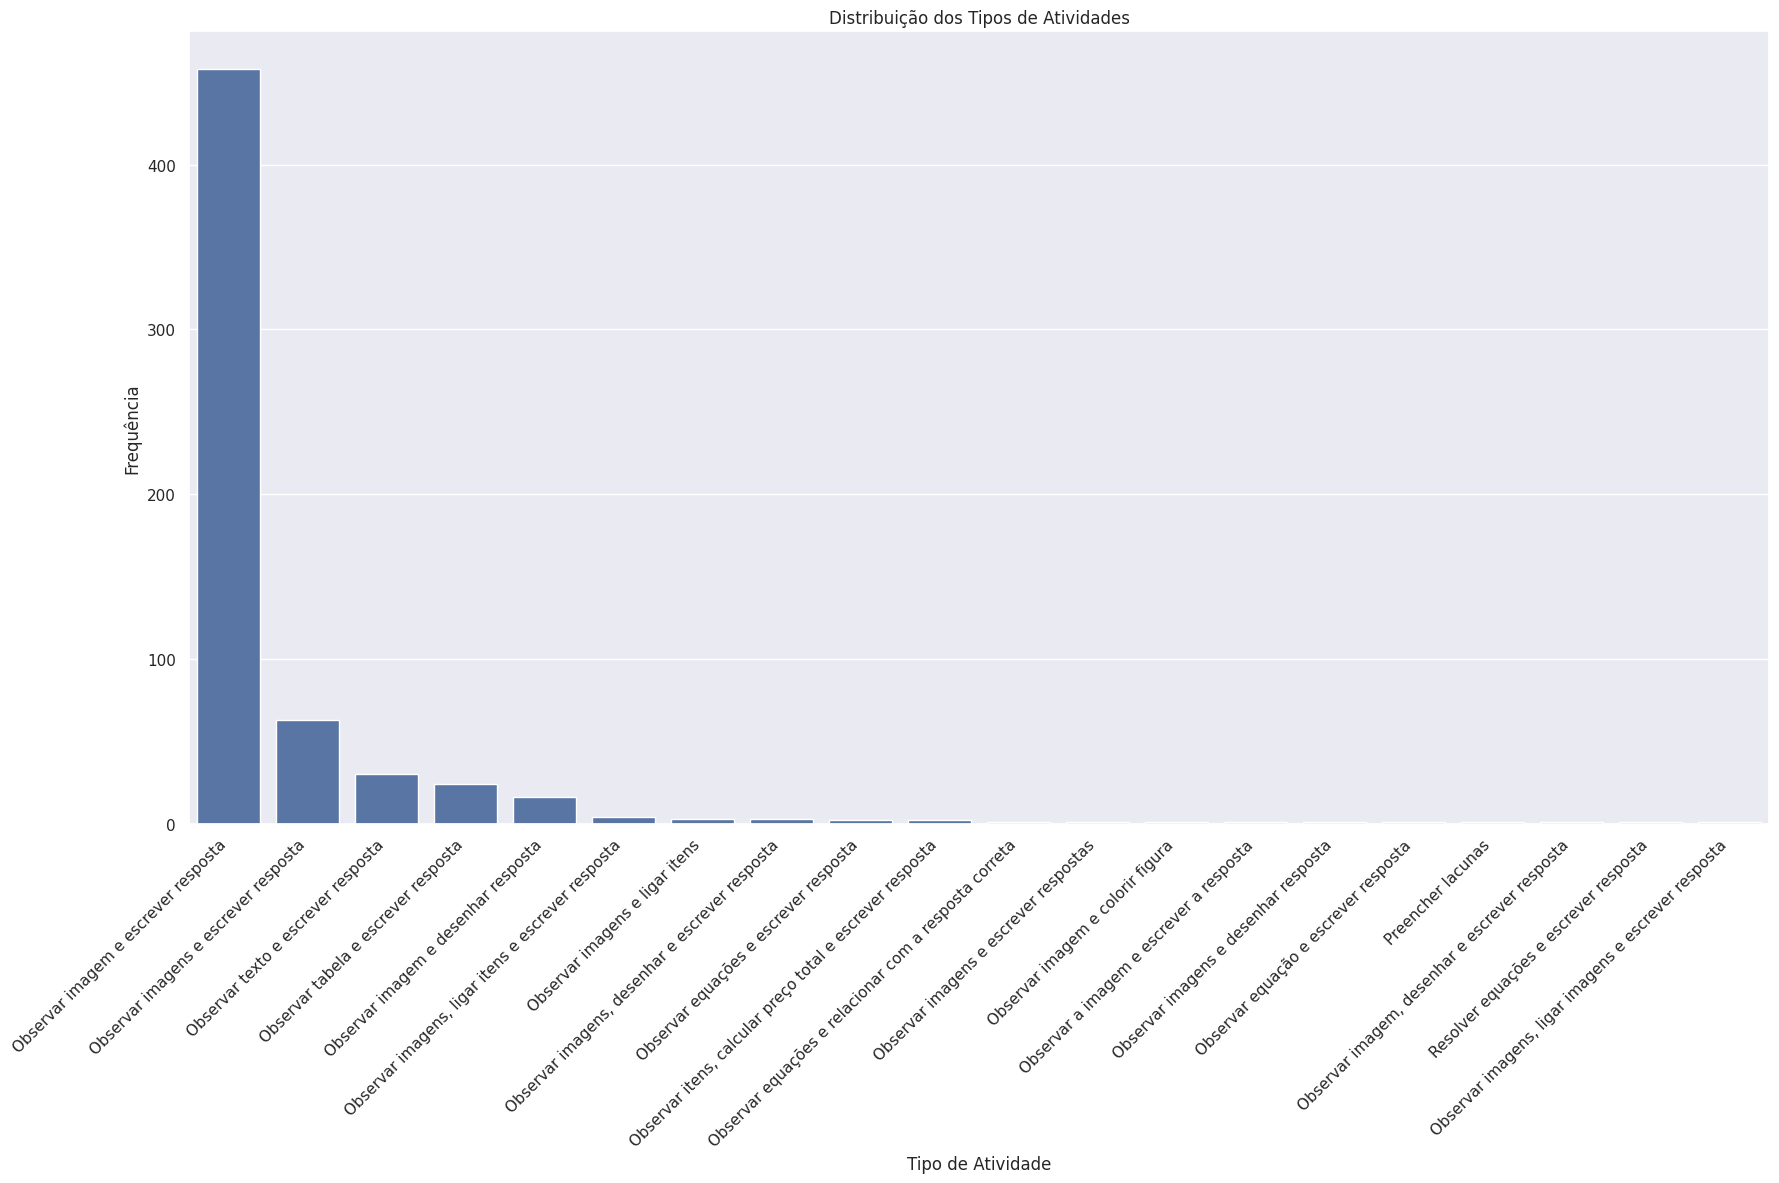

In [25]:
translation = {
    "observe text, write answer": "Observar texto e escrever resposta",
    "observe images, link items, write answer": "Observar imagens, ligar itens e escrever resposta",
    "observe table, write answer": "Observar tabela e escrever resposta",
    "observe image, write answer": "Observar imagem e escrever resposta",
    "observe images, write answer": "Observar imagens e escrever resposta",
    "solve the equations, write answer": "Resolver equações e escrever resposta",
    "observe images, link items": "Observar imagens e ligar itens",
    "observe equations, write answer": "Observar equações e escrever resposta",
    "observe image, draw answer": "Observar imagem e desenhar resposta",
    "observe items, calculate total price, write answer": "Observar itens, calcular preço total e escrever resposta",
    "observe images, draw answer": "Observar imagens e desenhar resposta",
    "observe image, draw answer, write answer": "Observar imagem, desenhar e escrever resposta",
    "observe images, draw answer, write answer": "Observar imagens, desenhar e escrever resposta",
    "fill in the gaps": "Preencher lacunas",
    "observe equation, write answer": "Observar equação e escrever resposta",
    "observe equations, match with correct answer": "Observar equações e relacionar com a resposta correta",
    "observe the image, write the answer": "Observar a imagem e escrever a resposta",
    "observe image, colorize picture": "Observar imagem e colorir figura",
    "observe images, write answers": "Observar imagens e escrever respostas",
    "observe images, link images, write answer": "Observar imagens, ligar imagens e escrever resposta"
}

# Construção do DataFrame
df = pd.DataFrame(
    [(translation[k], v) for k, v in count_layouts.items()],
    columns=["Categoria", "Quantidade"]
)

# Ordenar por frequência (opcional, mas recomendado)
df = df.sort_values("Quantidade", ascending=False)

# Configuração do gráfico
sns.set_theme()
plt.figure(figsize=(18, 12))
sns.barplot(
    data=df,
    x="Categoria",
    y="Quantidade"
)


plt.xticks(rotation=45, ha="right")
plt.xlabel("Tipo de Atividade")
plt.ylabel("Frequência")
plt.title("Distribuição dos Tipos de Atividades")

plt.tight_layout()
plt.show()

### Filtering the dataset

In [10]:
import random

random.seed(42)


def filter_percentage(dataset, percentages):

    return_new_dataset = defaultdict(list)

    for layout, examples in dataset.items():

        if not (layout in percentages):
            continue

        count = int(len(examples) * percentages[layout])

        return_new_dataset[layout] = random.sample(examples, count)

    return return_new_dataset


percentages = {
    "observe image, draw answer, write answer": 1,
    "observe image, write answer": 1,
    "observe table, write answer": 1,
    "observe images, link items": 1,
    "observe image, draw answer": 1,
    "observe images, write answer": 1,
    "observe equations, write answer": 1,
    "observe images, draw answer": 1,
    "observe images, draw answer, write answer": 1,
    "observe image, colorize picture": 1,
    "observe images, write answers": 1,
    "observe images, link images, write answer": 1,
    "solve the equations, write answer": 1,
    "observe items, calculate total price, write answer": 1,
    "fill in the gaps": 1,
    "observe equation, write answer": 1,
    "observe equations, match with correct answer": 1,
    "observe text, write answer": 1,
    "observe images, link items, write answer": 1,
    "Observe images, write answer": 1,
}

dataset_filtered = filter_percentage(dataset_layout, percentages)

count_layouts = {k: len(value) for k, value in dataset_filtered.items()}

count_layouts

{'observe text, write answer': 30,
 'observe images, link items, write answer': 4,
 'observe table, write answer': 24,
 'observe image, write answer': 458,
 'observe images, write answer': 63,
 'solve the equations, write answer': 1,
 'observe images, link items': 3,
 'observe equations, write answer': 2,
 'observe image, draw answer': 16,
 'observe items, calculate total price, write answer': 2,
 'observe images, draw answer': 1,
 'observe image, draw answer, write answer': 1,
 'observe images, draw answer, write answer': 3,
 'fill in the gaps': 1,
 'observe equation, write answer': 1,
 'observe equations, match with correct answer': 1,
 'observe image, colorize picture': 1,
 'observe images, write answers': 1,
 'observe images, link images, write answer': 1}

In [11]:
dataset = []

for layout, examples in dataset_filtered.items():
    dataset.extend(examples)

print(f"Total examples: {len(dataset)}")

Total examples: 614


### Getting the ID for the layouts

In [12]:
def iterate_files(path_xmls_blob):

    dict_task_examples = defaultdict(list)

    for html in glob.iglob(f"{path_xmls_blob}/*.html", recursive = True):
        if html.endswith("base.html"):
            continue
        
        with open(html, 'r', encoding='utf-8') as f:
            content = f.read()

            task = get_layout_example(content)

            name_file = os.path.basename(html).split(".")[0]

            dict_task_examples[task].append(name_file)

    
    return dict_task_examples

dict_task_examples = iterate_files("handmade_html_dataset/english/train/**")

for task, examples in dict_task_examples.items():
    print(f"Task: {task} - Examples: {len(examples)}")
    print(f"Examples IDs: {examples}")
    print()

print(dict_task_examples.keys())

Task: observe text, write answer - Examples: 30
Examples IDs: ['questao361', 'questao362', 'questao346', 'questao386', 'questao384', 'questao357', 'questao368', 'questao392', 'questao385', 'questao461', 'questao463', 'questao493', 'questao377', 'questao364', 'questao374', 'questao343', 'questao363', 'questao352', 'questao349', 'questao499', 'questao325', 'questao353', 'questao372', 'questao396', 'questao468', 'questao381', 'questao469', 'questao467', 'questao366', 'questao344']

Task: observe images, link items, write answer - Examples: 4
Examples IDs: ['questao216', 'questao211', 'questao220', 'questao229']

Task: observe table, write answer - Examples: 24
Examples IDs: ['questao332', 'questao456', 'questao448', 'questao322', 'questao334', 'questao464', 'questao401', 'questao406', 'questao338', 'questao478', 'example22', 'questao460', 'questao404', 'questao472', 'questao402', 'questao405', 'questao403', 'questao348', 'questao445', 'questao318', 'questao339', 'questao326', 'questao451'

In [13]:
dict_task_examples_test = iterate_files("handmade_html_dataset/english/test/**")

for key,value in dict_task_examples_test.items():
    print(f"Task: {key} - Examples: {len(value)}")
    print()

Task: observe images, write answer - Examples: 4

Task: observe image, write answer - Examples: 4

Task: observe image, draw answer - Examples: 4

Task: observe images, link items - Examples: 4



### Verifying the dataset with openAi scripts
- https://cookbook.openai.com/examples/chat_finetuning_data_prep

In [14]:
# Initial dataset stats
print("Num examples:", len(dataset))
print("First example:")
for message in dataset[0]["messages"]:
    print(message)

Num examples: 614
First example:
{'role': 'system', 'content': 'You are an assistant who helps a teacher create activities to help students learn'}
{'role': 'user', 'content': 'Create the complete structure of an **educational worksheet** designed to support student learning.\n\nThe worksheet must include a well-organized **visual layout**, using **HTML** to define structural elements and **CSS** to style and position content such as text, images, tables, and any other components that enhance the learning experience.\n\n### 📌 Layout Requirements:\n\n1. **Alignment with the Learning Task**  \n   All elements must be positioned and formatted in a way that directly supports the question or task proposed.\n   For example: if the student is asked to match images, the images should be arranged separately and spaced appropriately to allow for easy association.\n\n2. **HTML Structure with Descriptive Attributes**  \n   Each HTML element must include two key attributes:\n   - `alt`: For all ima

In [15]:
format_errors = defaultdict(int)

for ex in dataset:
    if not isinstance(ex, dict):
        format_errors["data_type"] += 1
        continue
        
    messages = ex.get("messages", None)
    if not messages:
        format_errors["missing_messages_list"] += 1
        continue
        
    for message in messages:
        if "role" not in message or "content" not in message:
            format_errors["message_missing_key"] += 1
        
        if any(k not in ("role", "content", "name", "function_call", "weight") for k in message):
            format_errors["message_unrecognized_key"] += 1
        
        if message.get("role", None) not in ("system", "user", "assistant", "function"):
            format_errors["unrecognized_role"] += 1
            
        content = message.get("content", None)
        function_call = message.get("function_call", None)
        
        if (not content and not function_call) or not isinstance(content, str):
            format_errors["missing_content"] += 1
    
    if not any(message.get("role", None) == "assistant" for message in messages):
        format_errors["example_missing_assistant_message"] += 1

if format_errors:
    print("Found errors:")
    for k, v in format_errors.items():
        print(f"{k}: {v}")
else:
    print("No errors found")

No errors found


In [16]:
encoding = tiktoken.get_encoding("cl100k_base")

# not exact!
# simplified from https://github.com/openai/openai-cookbook/blob/main/examples/How_to_count_tokens_with_tiktoken.ipynb
def num_tokens_from_messages(messages, tokens_per_message=3, tokens_per_name=1):
    num_tokens = 0
    for message in messages:
        num_tokens += tokens_per_message
        for key, value in message.items():
            num_tokens += len(encoding.encode(value))
            if key == "name":
                num_tokens += tokens_per_name
    num_tokens += 3
    return num_tokens

def num_assistant_tokens_from_messages(messages):
    num_tokens = 0
    for message in messages:
        if message["role"] == "assistant":
            num_tokens += len(encoding.encode(message["content"]))
    return num_tokens

def print_distribution(values, name):
    print(f"\n#### Distribution of {name}:")
    print(f"min / max: {min(values)}, {max(values)}")
    print(f"mean / median: {np.mean(values)}, {np.median(values)}")
    print(f"p5 / p95: {np.quantile(values, 0.1)}, {np.quantile(values, 0.9)}")

In [17]:
# Warnings and tokens counts
n_missing_system = 0
n_missing_user = 0
n_messages = []
convo_lens = []
assistant_message_lens = []

for ex in dataset:
    messages = ex["messages"]
    if not any(message["role"] == "system" for message in messages):
        n_missing_system += 1
    if not any(message["role"] == "user" for message in messages):
        n_missing_user += 1
    n_messages.append(len(messages))
    convo_lens.append(num_tokens_from_messages(messages))
    assistant_message_lens.append(num_assistant_tokens_from_messages(messages))
    
print("Num examples missing system message:", n_missing_system)
print("Num examples missing user message:", n_missing_user)
print_distribution(n_messages, "num_messages_per_example")
print_distribution(convo_lens, "num_total_tokens_per_example")
print_distribution(assistant_message_lens, "num_assistant_tokens_per_example")
n_too_long = sum(l > 4096 for l in convo_lens)
print(f"\n{n_too_long} examples may be over the 4096 token limit, they will be truncated during fine-tuning")

Num examples missing system message: 0
Num examples missing user message: 0

#### Distribution of num_messages_per_example:
min / max: 3, 3
mean / median: 3.0, 3.0
p5 / p95: 3.0, 3.0

#### Distribution of num_total_tokens_per_example:
min / max: 1236, 2337
mean / median: 1573.013029315961, 1514.0
p5 / p95: 1401.0, 1836.7

#### Distribution of num_assistant_tokens_per_example:
min / max: 326, 1428
mean / median: 660.2377850162867, 601.5
p5 / p95: 489.3, 925.4000000000001

0 examples may be over the 4096 token limit, they will be truncated during fine-tuning


In [18]:
# Pricing and default n_epochs estimate
MAX_TOKENS_PER_EXAMPLE = 10000000

TARGET_EPOCHS = 12
MIN_TARGET_EXAMPLES = 100
MAX_TARGET_EXAMPLES = 25000
MIN_DEFAULT_EPOCHS = 1
MAX_DEFAULT_EPOCHS = 25

n_epochs = TARGET_EPOCHS
n_train_examples = len(dataset)
if n_train_examples * TARGET_EPOCHS < MIN_TARGET_EXAMPLES:
    n_epochs = min(MAX_DEFAULT_EPOCHS, MIN_TARGET_EXAMPLES // n_train_examples)
elif n_train_examples * TARGET_EPOCHS > MAX_TARGET_EXAMPLES:
    n_epochs = max(MIN_DEFAULT_EPOCHS, MAX_TARGET_EXAMPLES // n_train_examples)

n_billing_tokens_in_dataset = sum(min(MAX_TOKENS_PER_EXAMPLE, length) for length in convo_lens)
print(f"Dataset has ~{n_billing_tokens_in_dataset} tokens that will be charged for during training")
print(f"By default, you'll train for {n_epochs} epochs on this dataset")
print(f"By default, you'll be charged for ~{n_epochs * n_billing_tokens_in_dataset} tokens")

Dataset has ~965830 tokens that will be charged for during training
By default, you'll train for 12 epochs on this dataset
By default, you'll be charged for ~11589960 tokens


In [19]:
try:
    os.remove('data/train_gpt.jsonl')
except:
    pass
with open("data/train_gpt.jsonl","a") as file:
	count = 0
	for line in dataset:
		file.write(json.dumps(line,ensure_ascii=False))
		count += 1
		if count != len(dataset):
			file.write('\n')

### No errors in the dataset, so lets proceed to the train

In [20]:
file_id = client.files.create(
	file=open("data/train_gpt.jsonl", "rb"),
	purpose="fine-tune"
)

In [22]:
EPOCHS = 5
BATCH_SIZE = 20
LEARNING_RATE = 6

In [ ]:
client.fine_tuning.jobs.create( # started with 918 credits
	training_file=file_id.id, 
	model="gpt-4.1-2025-04-14", 
	hyperparameters={
		"n_epochs": EPOCHS,	
		"batch_size": BATCH_SIZE,
		"learning_rate_multiplier": LEARNING_RATE
	}
)

FineTuningJob(id='ftjob-XBO4HA5JxbqAgRIPdO0CLnPx', created_at=1764777251, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size=20, learning_rate_multiplier=6.0, n_epochs=5), model='gpt-3.5-turbo-1106', object='fine_tuning.job', organization_id='org-b5IKFiP0PAa1t37kEErJkkNT', result_files=[], seed=1539710294, status='validating_files', trained_tokens=None, training_file='file-Cs14q1Hr4UZQK3vvbeRJMv', validation_file=None, estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=20, learning_rate_multiplier=6.0, n_epochs=5))), user_provided_suffix=None, usage_metrics=None, shared_with_openai=False, eval_id=None)

### After fine-tuning finish in the dashboard, you can make infers

In [112]:
def make_request_gpt(prompt, parameters, model, temperature = 1):
    
    para = ""
    for key, value in parameters.items():
        para += f"{key}: {value}\n"
    
    prompt = prompt.replace("<parameters>",para)
    
    completion = client.chat.completions.create(
		model=model,
		temperature= temperature,
		messages=[
			{"role": "system", "content": "You are an assistant who helps a teacher create activities to help students learn"},
			{"role": "user", "content": prompt}
		]	
	)

    output = completion.choices[0].message.to_dict()['content']
    
    return prompt + "\n" + output

In [113]:
PROMPT = \
f"""
{PROMPT_PART_1}

<parameters>

{PROMPT_PART_2}
"""
parameters = [

{"level": "2nd year of fundamental",
"subject": "addition",
"theme": "snacks",
"sheet width": "700px",
"layout": "observe image, write answer"}
,

# {"level": "2nd year of fundamental",
# "subject": "addition",
# "theme": "snacks",
# "sheet width": "700px",
# "layout": "observe images, write answer"}
# ,

# {"level": "2nd year of fundamental",
# "subject": "addition",
# "theme": "snacks",
# "sheet width": "700px",
# "layout": "observe image, draw answer"}
# ,
{"level": "2nd year of fundamental",
"subject": "addition",
"theme": "snacks",
"sheet width": "700px",
"layout": "observe images, draw answer"},

{"level": "2nd year of fundamental",
"subject": "addition",
"theme": "snacks",
"sheet width": "700px",
"layout": "observe images, link images"},

# ,

# {"level": "2nd year of fundamental",
# "subject": "addition",
# "theme": "toy cars",
# "sheet width": "600px",
# "layout": "observe images, link images"}
# ,

# {"level": "2nd year of fundamental",
# "subject": "addition",
# "theme": "toy cars",
# "sheet width": "600px",
# "layout": "observe images, write answer"}
# ,

{"level": "2nd year of fundamental",
"subject": "addition",
"theme": "underwater",
"sheet width": "600px",
"layout": "observe image, write answer"}
,

# {"level": "2nd year of fundamental",
# "subject": "addition",
# "theme": "underwater",
# "sheet width": "600px",
# "layout": "observe image, link images"}

# ,

{"level": "2nd year of fundamental",
"subject": "addition",
"theme": "underwater",
"sheet width": "600px",
"layout": "observe images, draw answer"}
,

{"level": "2nd year of fundamental",
"subject": "addition",
"theme": "underwater",
"sheet width": "600px",
"layout": "observe images, link images"}
,

# {"level": "2nd year of fundamental",
# "subject": "subtraction",
# "theme": "fireworks",
# "sheet width": "800px",
# "layout": "observe image, draw answer"}
# ,

# {"level": "2nd year of fundamental",
# "subject": "subtraction",
# "theme": "fireworks",
# "sheet width": "800px",
# "layout": "observe image, write answer"}
]



In [ ]:
file_to_save_predictions = str(datetime.now()) + ".txt"
MODEL = "ft:gpt-3.5-turbo-0125:ufcg::BTEw6z95" ## model trained with all of the dataset
TEMPERATURE = 0.5


for parameter in parameters:
	output = make_request_gpt(PROMPT, parameter, MODEL, TEMPERATURE)

	with open(f"runs/{file_to_save_predictions}","a",encoding='utf-8') as file:
		file.write("\n---------------------------------------------------------------------------------------------------------------\n")
		file.write(output)
	

In [117]:
line = [
    MODEL,
	'', 
	'', 
	'', 
	EPOCHS, 
	BATCH_SIZE, 
	'', 
	'', 
	'',
	LEARNING_RATE, 
	'', 
	'', 
	file_to_save_predictions
]
if os.path.exists("runs/parameters_train.csv"):
    dataFrame = pd.read_csv("runs/parameters_train.csv")
    dataFrame = pd.concat([dataFrame,pd.DataFrame([line],columns=dataFrame.columns)],ignore_index=True)
else:
    dataFrame = pd.DataFrame([line],columns = ["model_name","lora_r", "lora_alpha", "lora_dropout", "num_train_epochs", "per_device_train_batch_size", "per_device_eval_batch_size", "gradient_accumulation_steps", "max_grad_norm", "learning_rate", "weight_decay", "optim", "file_to_save_predictions"])
dataFrame.to_csv("runs/parameters_train.csv",index=False)
    